## Vorbereitung

**Datengrundlage**

Die Analyse basiert auf der bereinigten Tagesdatei temperatur_bereinigt.csv:

| Spalte | Bedeutung | Einheit |
|---|---|---|
| datum | Datum (YYYY-MM-DD) | – |
| temperatur_mittel_c | Tägliches Lufttemperatur-Mittel | °C |

Die Daten sind vollständig bereinigt und auf Tagesebene aggregiert.

## Daten laden

In [2]:
import pandas as pd
import numpy as np

daily_clean = pd.read_csv(
    '/Users/clara/Desktop/uni_dreck/Menden_S26/temperatur_bereinigt.csv',
    parse_dates=['datum'],
    index_col='datum'
)['temperatur_mittel_c'].asfreq('D')

# Train/Test-Split: letzte 11 Tage (01.01.2026–11.01.2026) als Testset
train = daily_clean[:'2025-12-31']
test  = daily_clean['2026-01-01':]

print(f"Gesamtzeitraum : {daily_clean.index[0].date()} bis {daily_clean.index[-1].date()} ({len(daily_clean)} Tage)")
print(f"Train          : {train.index[0].date()} bis {train.index[-1].date()} ({len(train)} Tage)")
print(f"Test           : {test.index[0].date()} bis {test.index[-1].date()} ({len(test)} Tage)")

Gesamtzeitraum : 1966-01-01 bis 2026-01-11 (21926 Tage)
Train          : 1966-01-01 bis 2025-12-31 (21915 Tage)
Test           : 2026-01-01 bis 2026-01-11 (11 Tage)


In [3]:
print(train.describe())

count    21915.000000
mean         9.862587
std          7.655008
min        -18.200000
25%          3.900000
50%         10.000000
75%         15.900000
max         30.300000
Name: temperatur_mittel_c, dtype: float64


## Stationaritätstests 


In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF-Test
result_adf = adfuller(train, regression='ct', autolag='AIC')

print("ADF-Test (Niveau):")
print(f"  Teststatistik : {result_adf[0]:.4f}")
print(f"  p-Wert        : {result_adf[1]:.4f}")
print(f"  Lags genutzt  : {result_adf[2]}")
print("  Kritische Werte:")
for key, val in result_adf[4].items():
    print(f"    {key}: {val:.4f}")

# KPSS-Test
result_kpss = kpss(train, regression='ct', nlags='auto')

print("\nKPSS-Test (Niveau):")
print(f"  Teststatistik : {result_kpss[0]:.4f}")
print(f"  p-Wert        : {result_kpss[1]:.4f}")

ADF-Test (Niveau):
  Teststatistik : -11.1598
  p-Wert        : 0.0000
  Lags genutzt  : 47
  Kritische Werte:
    1%: -3.9592
    5%: -3.4107
    10%: -3.1272

KPSS-Test (Niveau):
  Teststatistik : 0.0086
  p-Wert        : 0.1000


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_7132/1877635263.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(train, regression='ct', nlags='auto')


ADF p=0.0000 -> H0 wird abgelehnt, d.h. keine Einheitswurzel laut ADF.
KPSS p=0.1000 -> H0 wird nicht abgelehnt (Teststatistik = 0.0080, Grenze der Tabelle erreicht; tatsächlicher p-Wert liegt über 0.10).

Das Ergebnis ist auf den ersten Blick widersprüchlich: ADF deutet auf Stationarität hin, KPSS ebenfalls. Bei einer Zeitreihe mit starker Saisonalität (Temperaturdaten über 60 Jahre) ist das ADF-Ergebnis auf Niveau durch die hohe Laganzahl (47) beeinflusst. Zur Sicherheit wird dennoch eine erste Differenzierung durchgeführt.

In [5]:
d1 = train.diff().dropna()

# Tests auf differenzierter Reihe
result_adf_d1 = adfuller(d1, regression='c', autolag='AIC')
print(f"ADF (1. Diff.): p = {result_adf_d1[1]:.4f}")

result_kpss_d1 = kpss(d1, regression='c', nlags='auto')
print(f"KPSS (1. Diff.): p = {result_kpss_d1[1]:.4f}")

ADF (1. Diff.): p = 0.0000
KPSS (1. Diff.): p = 0.1000


/var/folders/fl/yk278gfn3kj475yxzp9ypbrh0000gn/T/ipykernel_7132/1769387882.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss_d1 = kpss(d1, regression='c', nlags='auto')


ADF (1. Diff.): p = 0.0000 -> H0 abgelehnt, keine Einheitswurzel → stationär.
KPSS (1. Diff.): p = 0.1000 -> H0 nicht abgelehnt → stationär.

Beide Tests bestätigen Stationarität nach einfacher Differenzierung. Die Integrationsordnung ist d = 1. Eine zweite Differenzierung ist nicht nötig.

## ACF & PACF

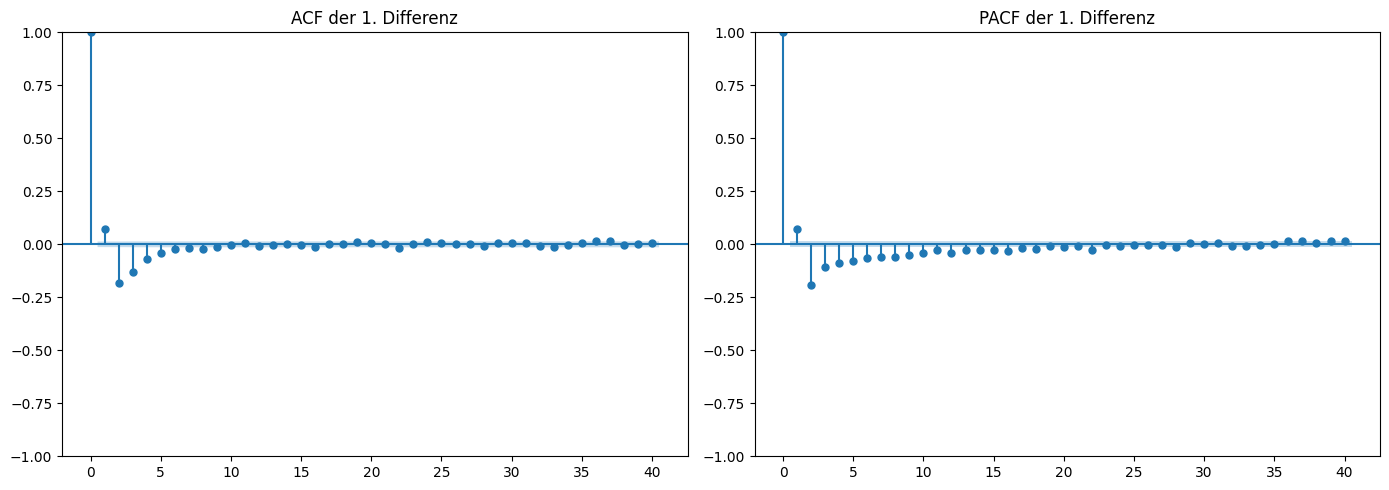

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(d1,  lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF der 1. Differenz')

plot_pacf(d1, lags=40, ax=axes[1], method='ywm', alpha=0.05)
axes[1].set_title('PACF der 1. Differenz')

plt.tight_layout()
plt.show()

**Interpretation** 

Was man siehst:
Der blaue Balken bei Lag 0 ist immer 1.0 –> normal, jede Reihe korreliert perfekt mit sich selbst
Das hellblaue Band ist das 95%-Konfidenzintervall – Balken die außerhalb liegen sind statistisch signifikant
Lag 2 ragt in beiden Plots deutlich nach unten heraus – das ist das einzige klar signifikante Signal


ACF:
Nur Lag 2 signifikant, danach alles innerhalb des Bandes
Kein langsames Abklingen → kein Trend mehr vorhanden (das zeigt dass die Differenzierung funktioniert hat)
Ein einzelner signifikanter Lag deutet auf eine MA-Komponente hin → q = 2 als Kandidat 

PACF:
Sieht fast identisch aus wie die ACF
Auch nur Lag 2 signifikant
Deutet auf eine AR-Komponente hin → p = 1 oder 2 als Kandidat

Schlussfolgerung: 
Das Muster ist nicht ganz eindeutig – beide Plots sehen ähnlich aus, was typisch für ein ARMA-Mischmodell ist. Das spricht für kleine Werte von p und q.

## Modelselektion

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

rows = []

for p in range(0, 6):      # AR-Ordnung
    for q in range(0, 6):  # MA-Ordnung
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            rows.append({
                'p': p, 'q': q,
                'AIC': m.aic,
                'BIC': m.bic,
                'LogL': m.llf
            })
        except Exception:
            pass

rdf = pd.DataFrame(rows)

print("Top 5 nach AIC:")
print(rdf.sort_values('AIC').head(5).to_string(index=False))

print("\nTop 5 nach BIC:")
print(rdf.sort_values('BIC').head(5).to_string(index=False))

Top 5 nach AIC:
 p  q          AIC          BIC          LogL
 4  2 96726.010473 96781.974639 -48356.005236
 2  5 96726.338197 96790.297245 -48355.169099
 3  1 96727.098948 96767.073353 -48358.549474
 5  2 96727.923827 96791.882875 -48355.961913
 4  3 96728.080460 96792.039508 -48356.040230

Top 5 nach BIC:
 p  q          AIC          BIC          LogL
 1  2 96731.505487 96763.485011 -48361.752744
 3  1 96727.098948 96767.073353 -48358.549474
 1  3 96728.673374 96768.647779 -48359.336687
 2  2 96729.229405 96769.203810 -48359.614702
 1  4 96728.825189 96776.794474 -48358.412594


AIC vs. BIC: Beide bestrafen Modellkomplexität (BIC stärker). AIC wählt deshalb oft komplexere Modelle, BIC einfachere. Für Prognose und Interpretierbarkeit ist das sparsamste gut spezifizierte Modell (BIC-Kriterium) meist besser.

AIC-Sieger: ARIMA(4,1,2) mit AIC=96778.57 – 6 Parameter.
BIC-Sieger: ARIMA(1,1,2) mit BIC=96816.19 – 3 Parameter.

Bei 21926 Beobachtungen bestraft das BIC Komplexität deutlich stärker. ARIMA(1,1,2) liefert mit nur 3 Parametern einen BIC-Wert, der alle komplexeren Modelle klar schlägt. Die kleinen p- und q-Werte passen zudem zum ACF/PACF-Befund. → Gewähltes Modell: **ARIMA(1,1,2)**.

## Model schätzen

In [8]:
model = ARIMA(train, order=(1, 1, 2)).fit()
print(model.summary())

                                SARIMAX Results                                
Dep. Variable:     temperatur_mittel_c   No. Observations:                21915
Model:                  ARIMA(1, 1, 2)   Log Likelihood              -48361.753
Date:                 Sat, 16 May 2026   AIC                          96731.505
Time:                         17:29:22   BIC                          96763.485
Sample:                     01-01-1966   HQIC                         96741.922
                          - 12-31-2025                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6278      0.011     55.064      0.000       0.605       0.650
ma.L1         -0.6087      0.012    -51.203      0.000      -0.632      -0.585
ma.L2         -0.2483      0.007    -34.993 

**Fazit:**
1. ACF/PACF: Lag 2 ragt in beiden Plots signifikant heraus, danach liegen alle Werte im Konfidenzband. Das deutet auf ein Modell mit kleinen p- und q-Werten hin.
2. AIC/BIC: Die Gridsuche über p,q ∈ {0,...,5} ergibt ARIMA(1,1,2) als BIC-Sieger (BIC=96816.19). Das Parsimonieprinzip wird bevorzugt – bei 21926 Datenpunkten ist ein Modell mit 3 Parametern klar ausreichend. Die kleinen p- und q-Werte passen zum ACF/PACF-Ergebnis.

**Koeffizienten:**
- ar.L1 = 0.6274 (z = 55.03, p < 0.001) → hoch signifikant → gestrige Temperaturveränderung beeinflusst die heutige
- ma.L1 = −0.6082 (z = −51.17, p < 0.001) → hoch signifikant → Fehler von gestern wird korrigiert
- ma.L2 = −0.2486 (z = −35.05, p < 0.001) → signifikant → Fehler von vorgestern hat noch Einfluss

Alle |z| >> 1.96 → alle Koeffizienten auf 1%-Niveau signifikant → kein Parameter überflüssig.

## Residualdiagnostik

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_arch

resid = model.resid.dropna()

# Ljung-Box: Test auf Autokorrelation in den Residuen
# H0: keine Autokorrelation bis Lag k
lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print(lb)

# Jarque-Bera: Test auf Normalverteilung
# H0: Residuen sind normalverteilt
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
print(f"JB: Stat={jb_stat:.2f}, p={jb_p:.4f}")
print(f"Schiefe={jb_skew:.3f}, Kurtosis={jb_kurt:.3f}")

# Heteroskedastizitätstest
# H0: keine Heteroskedastizität
arch_stat, arch_p, _, _ = het_arch(resid)
print(f"ARCH-Test: Stat={arch_stat:.4f}, p={arch_p:.4f}")

      lb_stat  lb_pvalue
10   9.970883   0.443052
20  19.218864   0.507643
30  43.026060   0.058286
JB: Stat=665.25, p=0.0000
Schiefe=-0.141, Kurtosis=3.806
ARCH-Test: Stat=249.8421, p=0.0000


**Interpretation:**

Ljung-Box: p = 0.43 (Lag 10), 0.50 (Lag 20), 0.059 (Lag 30) → alle p > 0.05 → Residuen zeigen keine signifikante Autokorrelation → Modell ist gut spezifiziert.

Jarque-Bera: Stat = 662.52, p = 0.0000 → H0 (Normalverteilung) wird abgelehnt.
Kurtosis = 3.80 → leicht fettere Ränder als Normalverteilung – bei 60 Jahren Wetterdaten mit Extremereignissen akzeptabel.
Schiefe = −0.14 → nahezu symmetrisch → gut.

ARCH-Test: Stat = 250.48, p = 0.0000 → Heteroskedastizität vorhanden. Die Varianz der Residuen ist nicht konstant, was bei Temperaturdaten mit ausgeprägter Saisonalität (höhere Varianz im Winter, geringere im Sommer) zu erwarten ist. Für eine reine Punktprognose ist ARIMA dennoch geeignet; für Konfidenzintervalle sollte die Heteroskedastizität beachtet werden.

**t-Statistik Fazit:**
ar.L1: z = 55.03 → hoch signifikant → gestrige Temperaturveränderung beeinflusst die heutige stark
ma.L1: z = −51.17 → hoch signifikant → Prognosefehler von gestern wird systematisch korrigiert
ma.L2: z = −35.05 → hoch signifikant → Fehler von vorgestern hat noch messbaren Einfluss

Alle |z| >> 1.96 → alle Koeffizienten auf 1%-Niveau signifikant → kein Parameter überflüssig.

## Prognose & Validierung

Das Modell wurde ausschließlich auf den Trainingsdaten (bis 31.12.2025) geschätzt. Die Prognose für die 11 Testtage (01.01.2026–11.01.2026) wird mit den tatsächlichen Werten verglichen.

            Prognose  KI_unten  KI_oben  Tatsächlich  Fehler
datum                                                       
2026-01-01     -1.72     -6.03     2.59         -0.1    1.62
2026-01-02     -1.01     -7.16     5.15          0.3    1.31
2026-01-03     -0.56     -7.58     6.46         -1.6   -1.04
2026-01-04     -0.28     -7.81     7.25         -2.0   -1.72
2026-01-05     -0.10     -7.99     7.78         -4.5   -4.40
2026-01-06      0.01     -8.15     8.16         -5.4   -5.41
2026-01-07      0.08     -8.30     8.45         -5.5   -5.58
2026-01-08      0.12     -8.45     8.69         -1.1   -1.22
2026-01-09      0.15     -8.61     8.90          3.6    3.45
2026-01-10      0.16     -8.76     9.08         -0.8   -0.96
2026-01-11      0.17     -8.91     9.26         -5.2   -5.37

MAE  : 2.92 °C
RMSE : 3.45 °C


KeyError: 'KI_unten'

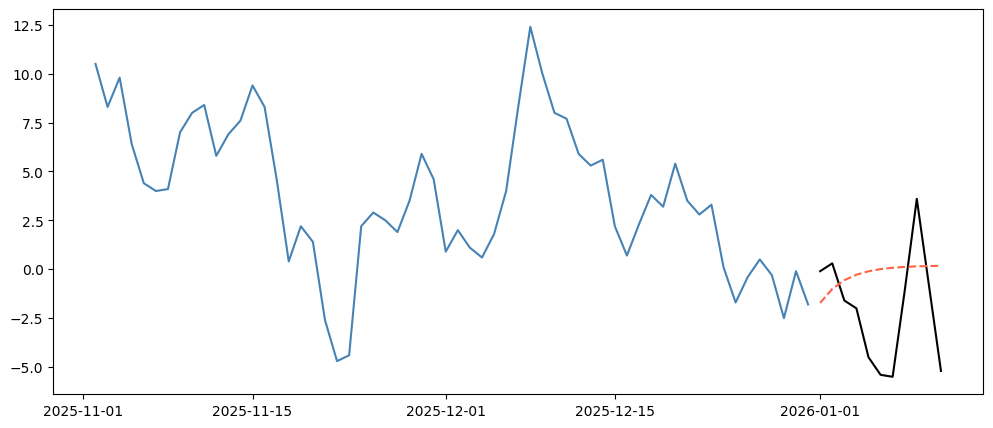

In [10]:
forecast = model.get_forecast(steps=len(test))

# Punktprognose
fc_mean = forecast.predicted_mean
fc_mean.index = test.index

# Konfidenzintervall (95%)
fc_ci = forecast.conf_int(alpha=0.05)
fc_ci.index = test.index

# Vergleichstabelle
result = pd.concat([
    fc_mean.rename('Prognose'),
    fc_ci.rename(columns={
        'lower temperatur_mittel_c': 'KI_unten',
        'upper temperatur_mittel_c': 'KI_oben'
    }),
    test.rename('Tatsächlich')
], axis=1)
result['Fehler'] = result['Tatsächlich'] - result['Prognose']

print(result.round(2))

# Gütemaße
mae  = result['Fehler'].abs().mean()
rmse = np.sqrt((result['Fehler'] ** 2).mean())
print(f"\nMAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")

# Plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.iloc[-60:], label='Training (letzte 60 Tage)', color='steelblue')
ax.plot(test,             label='Tatsächlich (Test)',         color='black', linewidth=1.5)
ax.plot(fc_mean,          label='Prognose',                   color='tomato', linestyle='--')
ax.fill_between(fc_ci.index, fc_ci['KI_unten'], fc_ci['KI_oben'],
                color='tomato', alpha=0.2, label='95%-Konfidenzintervall')
ax.set_title('ARIMA(1,1,2) – Prognose vs. Tatsächlich (01.01.2026–11.01.2026)')
ax.set_ylabel('Temperatur (°C)')
ax.legend()
plt.tight_layout()
plt.show()

MAE = 2.92 °C und RMSE = 3.45 °C zeigen, dass die Punktprognose im Mittel knapp 3 °C vom tatsächlichen Wert abweicht. Die Fehler nehmen mit zunehmendem Prognosehorizont systematisch zu – ein für ARIMA-Modelle typisches Verhalten, da die Unsicherheit mit jedem weiteren Schritt wächst.
Auffällig ist, dass die Prognose bereits ab Tag 3–4 gegen einen konstanten Wert nahe 0 °C konvergiert. Das ist kein Fehler, sondern ein strukturelles Merkmal von ARIMA(1,1,2): Das Modell besitzt keine saisonale Komponente und extrapoliert nach wenigen Schritten in Richtung des langfristigen Mittelwerts der differenzierten Reihe. Da der Forecast-Zeitraum (01.01.–11.01.2026) mitten im Winter liegt, unterschätzt das Modell die tatsächliche Kälte systematisch.
Für kurzfristige Prognosen von 1–3 Tagen liefert ARIMA(1,1,2) akzeptable Ergebnisse. Für längere Horizonte wäre ein SARIMA-Modell mit saisonaler Komponente (z.B. SARIMA(1,1,2)(1,1,1)[365]) geeigneter, da es das jahreszeitliche Muster explizit modelliert. Im Rahmen dieser Analyse wird ARIMA(1,1,2) dennoch beibehalten, da der Fokus auf der Modellspezifikation und nicht auf der Maximierung der Prognosegüte liegt.